In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Binary CNN scores
binary_dir_run1 = "/home/paul/Msci/dm_sets/run1_samples/"
binary_signal_dir_run1 = "/home/paul/Msci/dm_sets/run1_signal/"

signal_binary = pd.read_csv(binary_signal_dir_run1 + "run1_dt_ratio_0.6_ma_0.05_pi0_larcv_cropped_scores.csv")
nu_binary = pd.read_csv(binary_dir_run1 + "run1_NuMI_nu_overlay_larcv_cropped_scores.csv")
dirt_binary = pd.read_csv(binary_dir_run1 + "run1_NuMI_dirt_larcv_cropped_scores.csv")
offbeam_binary = pd.read_csv(binary_dir_run1 + "run1_offbeam_larcv_cropped_full_set_scores.csv")

# Multiclass CNN scores
multiclass_dir = "/home/paul/Msci/dm_sets_multiclass/run1/"

signal_multi = pd.read_csv(multiclass_dir + "run1_dt_ratio_0.6_ma_0.05_pi0_larcv_cropped_scores_multiclass.csv")
nu_multi = pd.read_csv(multiclass_dir + "run1_NuMI_nu_overlay_larcv_cropped_scores_multiclass.csv")
dirt_multi = pd.read_csv(multiclass_dir + "run1_NuMI_dirt_larcv_cropped_scores_multiclass.csv")
offbeam_multi = pd.read_csv(multiclass_dir + "run1_offbeam_larcv_cropped_full_set_scores_multiclass.csv")

print(f"Binary - Signal: {len(signal_binary)}, Nu: {len(nu_binary)}, Dirt: {len(dirt_binary)}, Offbeam: {len(offbeam_binary)}")
print(f"Multiclass - Signal: {len(signal_multi)}, Nu: {len(nu_multi)}, Dirt: {len(dirt_multi)}, Offbeam: {len(offbeam_multi)}")

Binary - Signal: 4219, Nu: 13770, Dirt: 3331, Offbeam: 3889
Multiclass - Signal: 4219, Nu: 13770, Dirt: 3331, Offbeam: 3889


In [3]:
# Binary: signal_score column
# Multiclass: p2 column (DM signal probability)

# Combine all backgrounds
bkg_binary = pd.concat([nu_binary, dirt_binary, offbeam_binary], ignore_index=True)
bkg_multi = pd.concat([nu_multi, dirt_multi, offbeam_multi], ignore_index=True)

# Create labels: 1 = signal, 0 = background
y_true_binary = np.concatenate([np.ones(len(signal_binary)), np.zeros(len(bkg_binary))])
y_true_multi = np.concatenate([np.ones(len(signal_multi)), np.zeros(len(bkg_multi))])

# Get scores
y_score_binary = np.concatenate([signal_binary['signal_score'], bkg_binary['signal_score']])
y_score_multi = np.concatenate([signal_multi['p2'], bkg_multi['p2']])

print(f"Binary - Total events: {len(y_true_binary)} (Signal: {int(y_true_binary.sum())}, Bkg: {int(len(y_true_binary) - y_true_binary.sum())})")
print(f"Multiclass - Total events: {len(y_true_multi)} (Signal: {int(y_true_multi.sum())}, Bkg: {int(len(y_true_multi) - y_true_multi.sum())})")

Binary - Total events: 25209 (Signal: 4219, Bkg: 20990)
Multiclass - Total events: 25209 (Signal: 4219, Bkg: 20990)


In [4]:
# Calculate ROC curves
fpr_binary, tpr_binary, _ = roc_curve(y_true_binary, y_score_binary)
fpr_multi, tpr_multi, _ = roc_curve(y_true_multi, y_score_multi)

# Calculate AUC
auc_binary = auc(fpr_binary, tpr_binary)
auc_multi = auc(fpr_multi, tpr_multi)

print(f"Binary CNN AUC: {auc_binary:.4f}")
print(f"Multiclass CNN AUC: {auc_multi:.4f}")

Binary CNN AUC: 0.9527
Multiclass CNN AUC: 0.9557


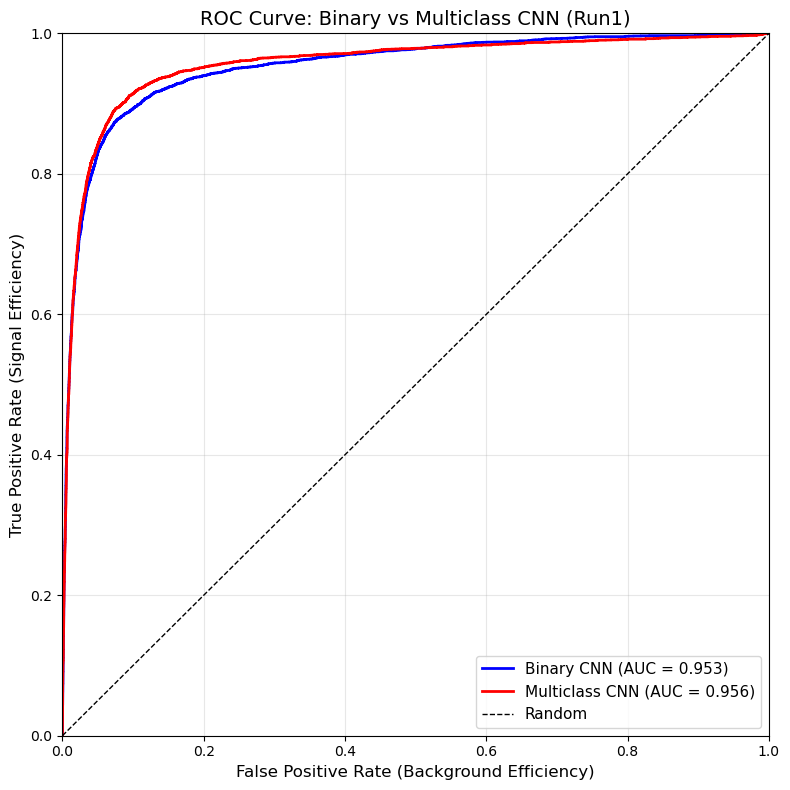

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(fpr_binary, tpr_binary, 'b-', lw=2, label=f'Binary CNN (AUC = {auc_binary:.3f})')
ax.plot(fpr_multi, tpr_multi, 'r-', lw=2, label=f'Multiclass CNN (AUC = {auc_multi:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')

ax.set_xlabel('False Positive Rate (Background Efficiency)', fontsize=12)
ax.set_ylabel('True Positive Rate (Signal Efficiency)', fontsize=12)
ax.set_title('ROC Curve (Run1), ratio=0.6, ma=0.05, dmode=pi0', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/paul/Msci/plots/roc_binary_vs_multiclass.png', dpi=300)
plt.savefig('/home/paul/Msci/plots/roc_binary_vs_multiclass.pdf')
plt.show()

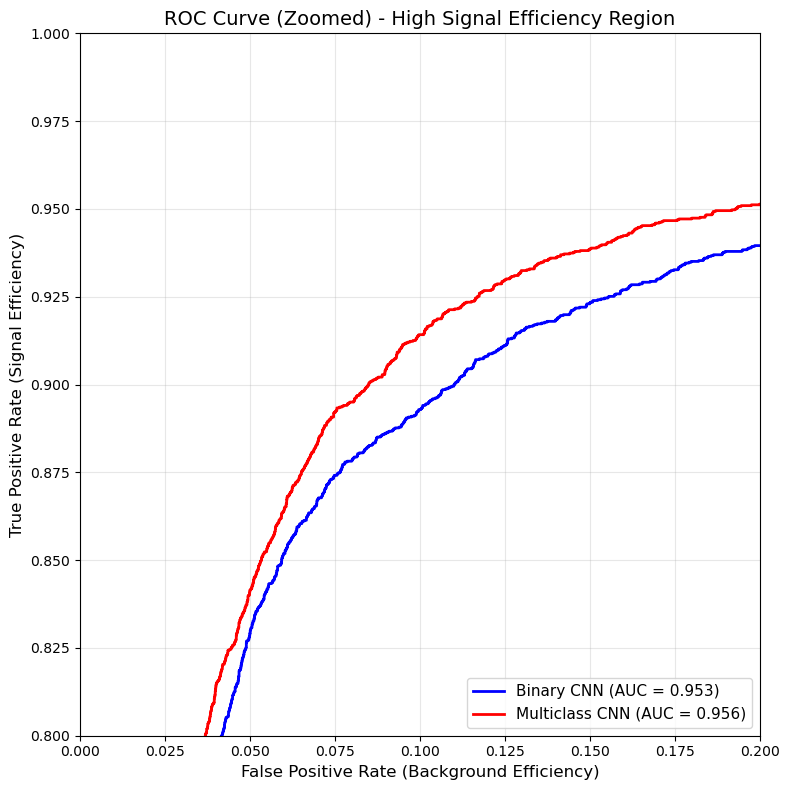

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(fpr_binary, tpr_binary, 'b-', lw=2, label=f'Binary CNN (AUC = {auc_binary:.3f})')
ax.plot(fpr_multi, tpr_multi, 'r-', lw=2, label=f'Multiclass CNN (AUC = {auc_multi:.3f})')

ax.set_xlabel('False Positive Rate (Background Efficiency)', fontsize=12)
ax.set_ylabel('True Positive Rate (Signal Efficiency)', fontsize=12)
ax.set_title('ROC Curve (Zoomed) - High Signal Efficiency Region', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 0.2])
ax.set_ylim([0.8, 1.0])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/paul/Msci/plots/roc_binary_vs_multiclass_zoomed.png', dpi=300)
plt.savefig('/home/paul/Msci/plots/roc_binary_vs_multiclass_zoomed.pdf')
plt.show()